# NumCompute Stream Demo

This notebook demonstrates the streaming decision tree framework.

It covers:

1. Loading CSV data using `numcompute.io`
2. Splitting data into chunks
3. Incremental training using `.partial_fit()`
4. Comparing a single decision tree with a bagging ensemble
5. Logging and visualising streaming metrics


In [46]:
import numpy as np

from numcompute.io import read_csv
from numcompute.preprocessing import StandardScaler
from numcompute.pipeline import Pipeline
from numcompute.tree import DecisionTreeClassifier
from numcompute.ensemble import EnsembleClassifier
from numcompute.stream import StreamTrainer
from numcompute.visualise import (
    plot_metric_over_time,
    compare_models,
    plot_predictions_vs_ground_truth,
)


## 1. Load CSV data using custom I/O

The data is loaded from `demo/stream_data.csv` using `read_csv()` from `io.py`.


In [47]:
from pathlib import Path

DATA_PATH = Path("demo/stream_data.csv")

if not DATA_PATH.exists():
    DATA_PATH = Path("stream_data.csv")

data = read_csv(
    str(DATA_PATH),
    dtype=float,
    skip_header=True,
)

X = data[:, :-1]
y = data[:, -1].astype(int)

print("Data path:", DATA_PATH)
print("X shape:", X.shape)
print("y shape:", y.shape)
print("First 5 labels:", y[:5])

Data path: stream_data.csv
X shape: (40, 4)
y shape: (40,)
First 5 labels: [0 0 0 0 0]


## 2. Split data into chunks

Each chunk simulates incoming streaming data.


In [48]:
chunk_size = 5
chunks = []

for start in range(0, X.shape[0], chunk_size):
    end = start + chunk_size
    chunks.append((X[start:end], y[start:end]))

print("Number of chunks:", len(chunks))
print("First chunk X shape:", chunks[0][0].shape)
print("First chunk y shape:", chunks[0][1].shape)


Number of chunks: 8
First chunk X shape: (5, 4)
First chunk y shape: (5,)


## 3. Build streaming models

Both models use the same pipeline interface:

`StandardScaler.partial_fit()` → model `.partial_fit()`


In [49]:
tree_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("model", DecisionTreeClassifier(
        max_depth=3,
        min_samples_split=2,
        max_features=None,
        criterion="gini",
    )),
])

ensemble_pipeline = Pipeline([
    ("scale", StandardScaler()),
    ("model", EnsembleClassifier(
        n_estimators=5,
        method="bagging",
        max_depth=3,
        min_samples_split=2,
        max_features=None,
        criterion="gini",
        random_state=42,
    )),
])

tree_trainer = StreamTrainer(tree_pipeline)
ensemble_trainer = StreamTrainer(ensemble_pipeline)


## 4. Train incrementally using `.partial_fit()`

Each chunk is processed one at a time.


In [50]:
tree_logs = []
ensemble_logs = []

for X_chunk, y_chunk in chunks:
    tree_logs.append(tree_trainer.fit_score_chunk(X_chunk, y_chunk))
    ensemble_logs.append(ensemble_trainer.fit_score_chunk(X_chunk, y_chunk))

print("Final decision tree log:")
print(tree_logs[-1])

print("\nFinal ensemble log:")
print(ensemble_logs[-1])


Final decision tree log:
{'chunk': 8, 'chunk_accuracy': 0.8, 'chunk_error': 0.19999999999999996, 'cumulative_accuracy': 0.875, 'memory_bytes': 288}

Final ensemble log:
{'chunk': 8, 'chunk_accuracy': 1.0, 'chunk_error': 0.0, 'cumulative_accuracy': 0.95, 'memory_bytes': 288}


## 5. Extract streaming metrics

In [51]:
tree_accuracy = [log["cumulative_accuracy"] for log in tree_logs]
ensemble_accuracy = [log["cumulative_accuracy"] for log in ensemble_logs]

tree_error = [log["chunk_error"] for log in tree_logs]
ensemble_error = [log["chunk_error"] for log in ensemble_logs]

print("Tree cumulative accuracy:", tree_accuracy)
print("Ensemble cumulative accuracy:", ensemble_accuracy)


Tree cumulative accuracy: [1.0, 1.0, 1.0, 1.0, 0.92, 0.9, 0.8857142857142857, 0.875]
Ensemble cumulative accuracy: [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9428571428571428, 0.95]


## 6. Visualise decision tree accuracy over time

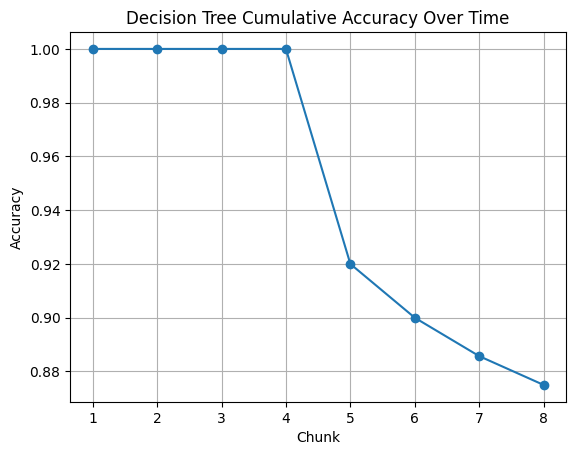

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Decision Tree Cumulative Accuracy Over Time'}, xlabel='Chunk', ylabel='Accuracy'>)

In [52]:
plot_metric_over_time(
    tree_accuracy,
    title="Decision Tree Cumulative Accuracy Over Time",
    ylabel="Accuracy",
)


## 7. Visualise decision tree error over time

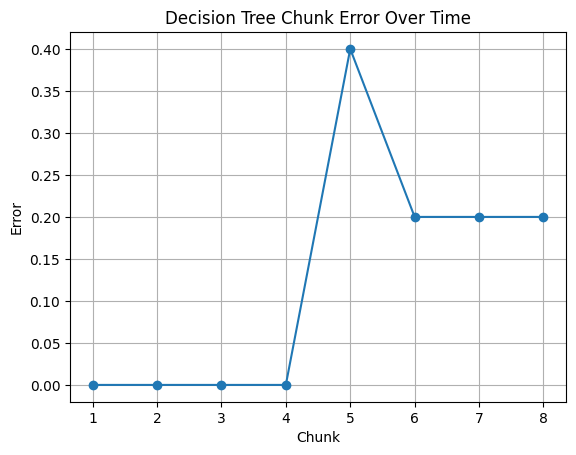

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Decision Tree Chunk Error Over Time'}, xlabel='Chunk', ylabel='Error'>)

In [53]:
plot_metric_over_time(
    tree_error,
    title="Decision Tree Chunk Error Over Time",
    ylabel="Error",
)


## 8. Compare decision tree and bagging ensemble

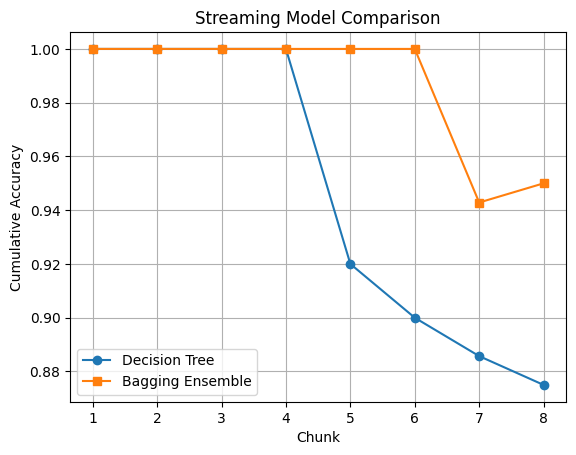

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Streaming Model Comparison'}, xlabel='Chunk', ylabel='Cumulative Accuracy'>)

In [54]:
compare_models(
    tree_accuracy,
    ensemble_accuracy,
    labels=["Decision Tree", "Bagging Ensemble"],
    title="Streaming Model Comparison",
    ylabel="Cumulative Accuracy",
)


## 9. Predictions vs ground truth on latest chunk

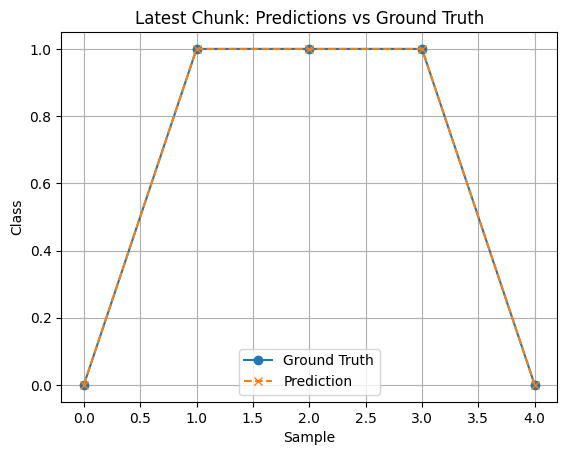

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Latest Chunk: Predictions vs Ground Truth'}, xlabel='Sample', ylabel='Class'>)

In [55]:
X_last, y_last = chunks[-1]
y_pred_last = ensemble_pipeline.predict(X_last)

plot_predictions_vs_ground_truth(
    y_last,
    y_pred_last,
    title="Latest Chunk: Predictions vs Ground Truth",
)


## Summary

This demo shows that the framework can:

- Load CSV data using the custom I/O module
- Process data chunk by chunk
- Train models incrementally using `.partial_fit()`
- Compare a single decision tree with a bagging ensemble
- Log and visualise streaming metrics
